# 01 / EDA & 문제 정의 - AI4I 2020 예지보전

**목표:** 데이터의 생김새를 파악하고, 이후 물리적 도메인 피처(Phase 2)/인사이트 발굴(Phase 3)의
방향을 잡는다. 물리 축(분포/관계)과 통계 축(기술통계/정규성/상관)을 함께 본다.

질문
1. 고장은 얼마나 희귀한가? 유형별 분포는?
2. 센서 6종은 어떤 분포를 갖는가? (정규? 균일?)
3. 센서 간 관계는? (물리적으로 말이 되는가)
4. 제품 등급(L/M/H)에 따라 무엇이 다른가?


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

_here = Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / 'src').is_dir()), _here)
sys.path.insert(0, str(ROOT))
from src.config import FIGDIR, load_raw

FIGDIR.mkdir(parents=True, exist_ok=True)

df = load_raw()
print('shape:', df.shape)
df.head()

shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# 컬럼
sensors = ['Air temperature [K]', 'Process temperature [K]',
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
fail_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
target = 'Machine failure'

print('dtypes:')
print(df.dtypes)
print('\n결측치 합계:', int(df.isna().sum().sum()))
print('중복 행:', int(df.duplicated().sum()))

dtypes:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

결측치 합계: 0
중복 행: 0


## 0. 식별자 & 데이터 누수(leakage) 점검

모델 입력으로 쓰면 안 되는 컬럼을 먼저 가려낸다.
- `UDI`, `Product ID` : 식별자(정보 없음 / 누수 위험)
- `TWF/HDF/PWF/OSF/RNF` : 타깃 `Machine failure`의 구성요소 -> 이진 예측 입력으로 쓰면 정답 누수

In [3]:
# 식별자 확인
print('UDI = 1..N 순번:', (df['UDI'].values == np.arange(1, len(df) + 1)).all())
print('Product ID 첫 글자 == Type 비율:', (df['Product ID'].str[0] == df['Type']).mean())
print('Product ID 고유값:', df['Product ID'].nunique(), '/', len(df))
#   => UDI: 순번, Product ID: (Type 첫글자 + 고유번호) -> 둘 다 식별자, 피처 제외

# 누수 점검: 하위 5개 모드가 Machine failure의 구성요소인가
any_mode = (df[fail_modes].sum(axis=1) > 0).astype(int)
agree = (any_mode == df[target]).mean()
print(f'\nany(고장모드) == Machine failure : {agree*100:.2f}% 일치, '
      f'불일치 {int((any_mode != df[target]).sum())}건')
print('   => 5개 모드 컬럼은 타깃 구성요소. 이진 고장예측 입력으로 쓰면 누수.')

# 사용 가능한 입력 피처 정의
feature_cols = sensors + ['Type']
drop_cols = ['UDI', 'Product ID'] + fail_modes
print('\n[입력 피처]', feature_cols)
print('[제외: 식별자/누수]', drop_cols)

UDI = 1..N 순번: True
Product ID 첫 글자 == Type 비율: 1.0
Product ID 고유값: 10000 / 10000

any(고장모드) == Machine failure : 99.73% 일치, 불일치 27건
   => 5개 모드 컬럼은 타깃 구성요소. 이진 고장예측 입력으로 쓰면 누수.

[입력 피처] ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type']
[제외: 식별자/누수] ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 1. 고장 비율 & 유형별 분포 - 불균형 확인

전체 고장률: 339/10000 = 3.39%

고장유형별 건수:
  TWF: 46 (0.46%)
  HDF: 115 (1.15%)
  PWF: 95 (0.95%)
  OSF: 98 (0.98%)
  RNF: 19 (0.19%)

동시 2개 이상 고장모드: 24건


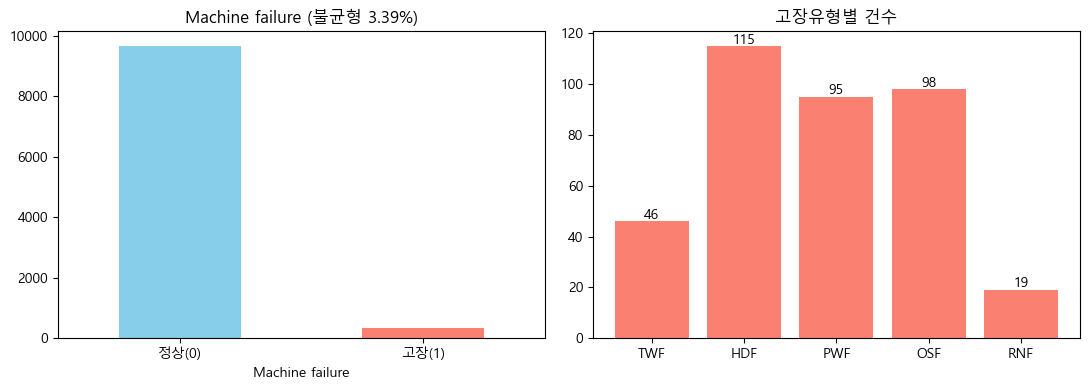

In [4]:
n = len(df)
fail_rate = df[target].mean()
print(f'전체 고장률: {df[target].sum()}/{n} = {fail_rate*100:.2f}%')
print('\n고장유형별 건수:')
for m in fail_modes:
    print(f'  {m}: {int(df[m].sum())} ({df[m].mean()*100:.2f}%)')

# 다중 고장(동시에 여러 모드) 확인
multi = df[df[fail_modes].sum(axis=1) >= 2]
print(f'\n동시 2개 이상 고장모드: {len(multi)}건')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[target].value_counts().plot.bar(ax=ax[0], color=['skyblue', 'salmon'])
ax[0].set_title(f'Machine failure (불균형 {fail_rate*100:.2f}%)')
ax[0].set_xticklabels(['정상(0)', '고장(1)'], rotation=0)
counts = [int(df[m].sum()) for m in fail_modes]
ax[1].bar(fail_modes, counts, color='salmon')
ax[1].set_title('고장유형별 건수')
for i, c in enumerate(counts):
    ax[1].text(i, c + 1, str(c), ha='center')
plt.tight_layout()
plt.savefig(FIGDIR / '01_failure_counts.png', dpi=120)
plt.show()

## 2. 센서 분포 (히스토그램)

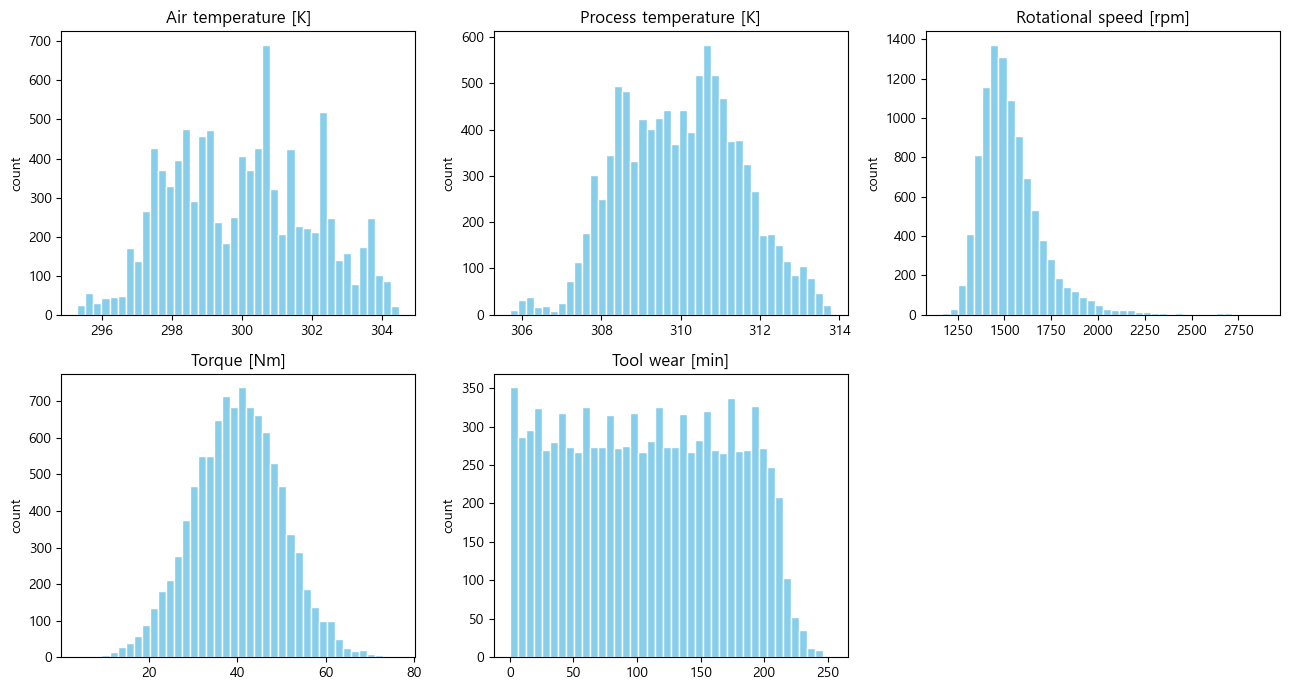

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), sensors):
    ax.hist(df[col], bins=40, color='skyblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('count')
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig(FIGDIR / '01_sensor_distributions.png', dpi=120)
plt.show()

## 3. 이상치 탐지

IQR(1.5x) 기준으로 이상치 수를 센 뒤, 그 값이 **측정 오류인지 물리적으로 타당한 값인지** 판단한다.
도메인 지식으로 설명되는 값이면 제거하지 않는다.

In [6]:
rows = []
for c in sensors:
    q1, q3 = df[c].quantile([.25, .75])
    iqr = q3 - q1
    lo = int((df[c] < q1 - 1.5 * iqr).sum())
    hi = int((df[c] > q3 + 1.5 * iqr).sum())
    rows.append({'sensor': c, '하단': lo, '상단': hi, '비율%': round((lo + hi) / len(df) * 100, 2)})
print(pd.DataFrame(rows).set_index('sensor').to_string())

# 회전속도 상단 이상치가 저토크에서 나오는지(=물리적 정상) 확인
q1, q3 = df['Rotational speed [rpm]'].quantile([.25, .75])
iqr = q3 - q1
hi_mask = df['Rotational speed [rpm]'] > q3 + 1.5 * iqr
print(f"\n회전속도 상단이상치 {int(hi_mask.sum())}개의 평균 토크: "
      f"{df.loc[hi_mask, 'Torque [Nm]'].mean():.1f} Nm "
      f"(전체 평균 {df['Torque [Nm]'].mean():.1f} Nm)")
print('=> 이상치는 저토크 구간에서 발생. P=tau*omega 반비례로 생긴 물리적 정상값 -> 제거하지 않음.')

                         하단   상단   비율%
sensor                                
Air temperature [K]       0    0  0.00
Process temperature [K]   0    0  0.00
Rotational speed [rpm]    0  418  4.18
Torque [Nm]              28   41  0.69
Tool wear [min]           0    0  0.00

회전속도 상단이상치 418개의 평균 토크: 18.9 Nm (전체 평균 40.0 Nm)
=> 이상치는 저토크 구간에서 발생. P=tau*omega 반비례로 생긴 물리적 정상값 -> 제거하지 않음.


## 4. 기술통계 - 평균/분산/왜도/첨도

왜도(skewness)/첨도(kurtosis)로 분포의 비대칭/뾰족함을 정량화한다.
이는 다음 셀의 정규성 검정 결과를 해석하는 근거가 된다.

In [7]:
desc = df[sensors].describe().T[['mean', 'std', 'min', 'max']]
desc['skew'] = df[sensors].skew()
desc['kurtosis'] = df[sensors].kurtosis()
desc.round(3)

,mean,std,min,max,skew,kurtosis
Air temperature [K],300.005,2.000,295.3,304.5,0.114,-0.836
Process temperature [K],310.006,1.484,305.7,313.8,0.015,-0.500
Rotational speed [rpm],1538.776,179.284,1168.0,2886.0,1.993,7.393
Torque [Nm],39.987,9.969,3.8,76.6,-0.010,-0.013
Tool wear [min],107.951,63.654,0.0,253.0,0.027,-1.167


## 5. 정규성 검정 - 이후 검정의 모수/비모수 선택 근거

- 표본이 n=10,000으로 크다. **Shapiro-Wilk는 n<=5000 권장**이라 신뢰구간이 왜곡되므로,
  대표본에 적합한 **D'Agostino-Pearson(normaltest)** 를 주 판정에 쓰고,
  Shapiro는 5000개 랜덤 서브샘플로 참고만 한다.
- 시각 확인은 **Q-Q 플롯**으로 한다.
- 결론이 '비정규'면 Phase 3에서 t-검정 대신 **Mann-Whitney U** 를 쓴다.

In [8]:
rng = np.random.default_rng(42)
rows = []
for col in sensors:
    x = df[col].values
    k2, p_dag = stats.normaltest(x)                      # D'Agostino-Pearson (대표본)
    sub = rng.choice(x, size=5000, replace=False)
    w, p_sw = stats.shapiro(sub)                          # 참고 (서브샘플)
    rows.append({'sensor': col, 'DAgostino_p': p_dag,
                 'Shapiro_p(5k)': p_sw,
                 '정규성(alpha=0.05)': '정규' if p_dag > 0.05 else '비정규'})
norm_tbl = pd.DataFrame(rows).set_index('sensor')
print(norm_tbl.to_string())
print('\n=> 비정규가 대부분이면 Phase 3는 비모수 검정(Mann-Whitney) 사용')

                           DAgostino_p  Shapiro_p(5k) 정규성(alpha=0.05)
sensor                                                               
Air temperature [K]      1.007250e-223   1.556380e-25             비정규
Process temperature [K]   2.929129e-42   1.778527e-16             비정규
Rotational speed [rpm]    0.000000e+00   3.076304e-54             비정규
Torque [Nm]               8.991517e-01   3.328239e-01              정규
Tool wear [min]           0.000000e+00   2.297797e-35             비정규

=> 비정규가 대부분이면 Phase 3는 비모수 검정(Mann-Whitney) 사용


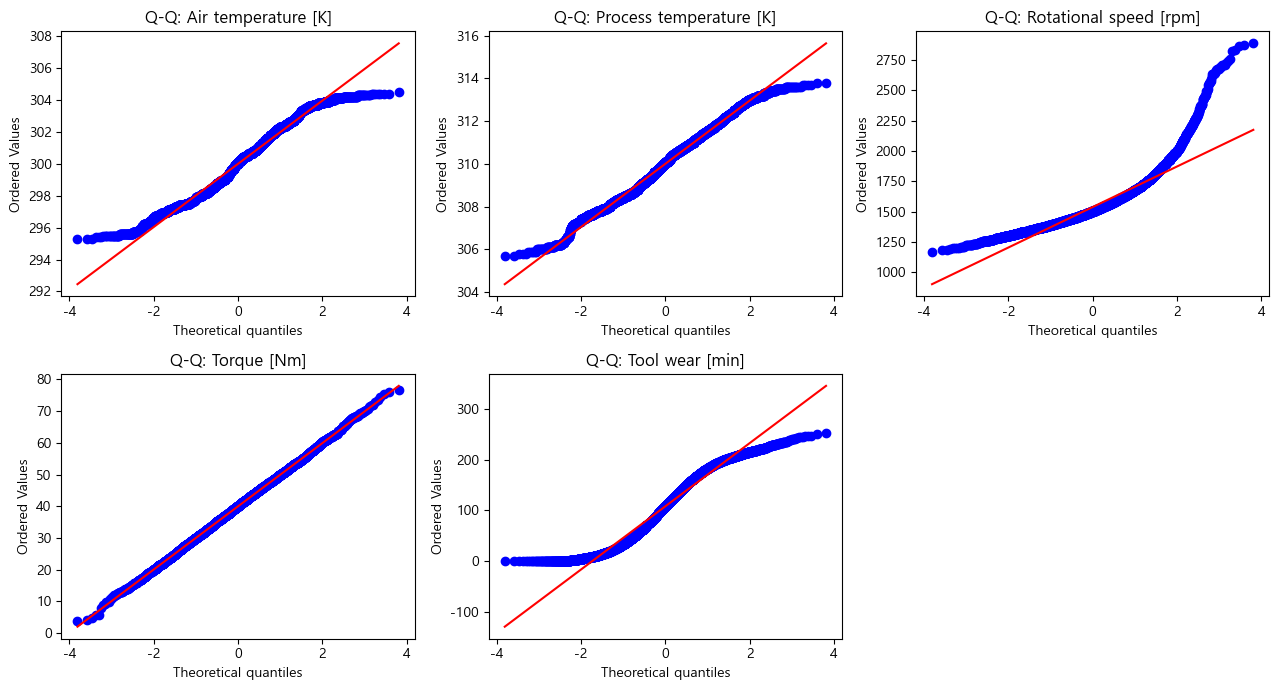

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), sensors):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}')
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig(FIGDIR / '01_qq_plots.png', dpi=120)
plt.show()

## 6. 상관관계 - Pearson & Spearman

- **Pearson**: 선형 관계. **Spearman**: 순위(단조) 관계 - 비정규/비선형에 강건.
- 도메인 지식 기반 예상: 회전속도up 이면 토크down (동력 일정 경향) -> 음의 상관이 보이면 물리적인 도메인과 일치.

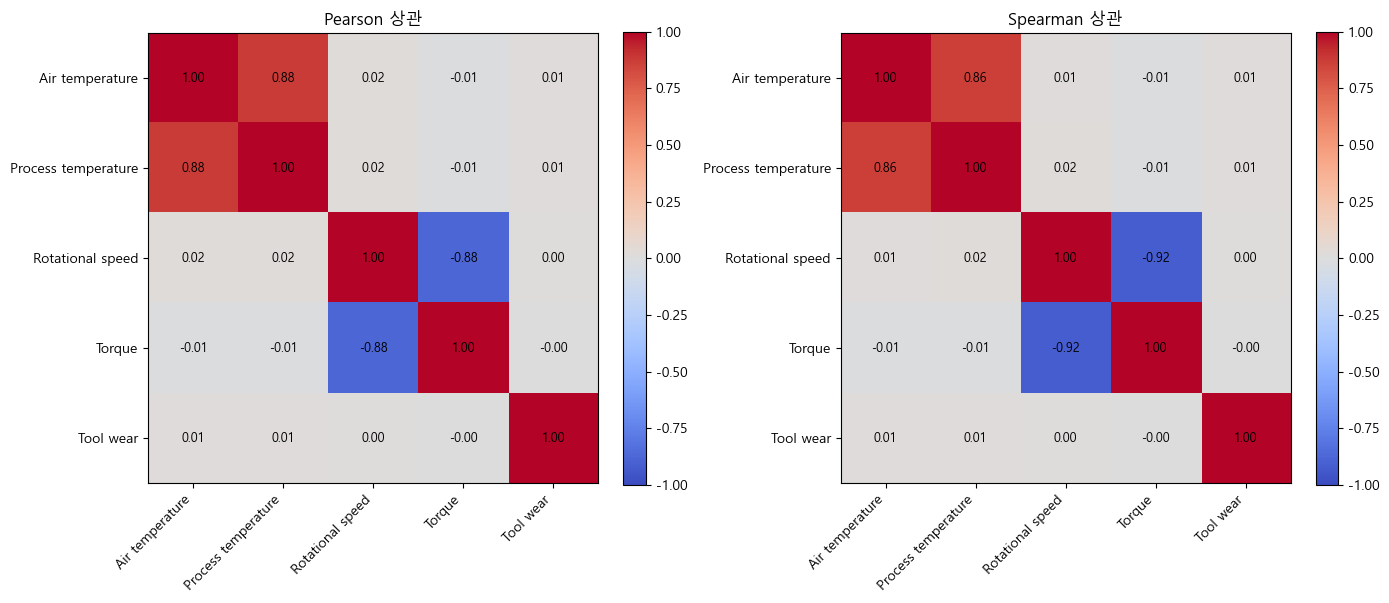

회전속도-토크 Pearson: -0.875


In [10]:
pear = df[sensors].corr(method='pearson')
spear = df[sensors].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (mat, name) in zip(axes, [(pear, 'Pearson'), (spear, 'Spearman')]):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(sensors)))
    ax.set_yticks(range(len(sensors)))
    short = [s.split(' [')[0] for s in sensors]
    ax.set_xticklabels(short, rotation=45, ha='right')
    ax.set_yticklabels(short)
    for i in range(len(sensors)):
        for j in range(len(sensors)):
            ax.text(j, i, f'{mat.iloc[i,j]:.2f}', ha='center', va='center',
                    color='black', fontsize=9)
    ax.set_title(f'{name} 상관')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIGDIR / '01_correlation.png', dpi=120)
plt.show()
print('회전속도-토크 Pearson:', round(pear.loc['Rotational speed [rpm]','Torque [Nm]'], 3))

## 7. 피처 <-> 타깃 관계 - 어떤 센서가 고장과 함께 움직이나

각 센서를 정상(0)/고장(1)으로 나눠 분포를 비교한다. (정식 유의성 검정은 Phase 3)

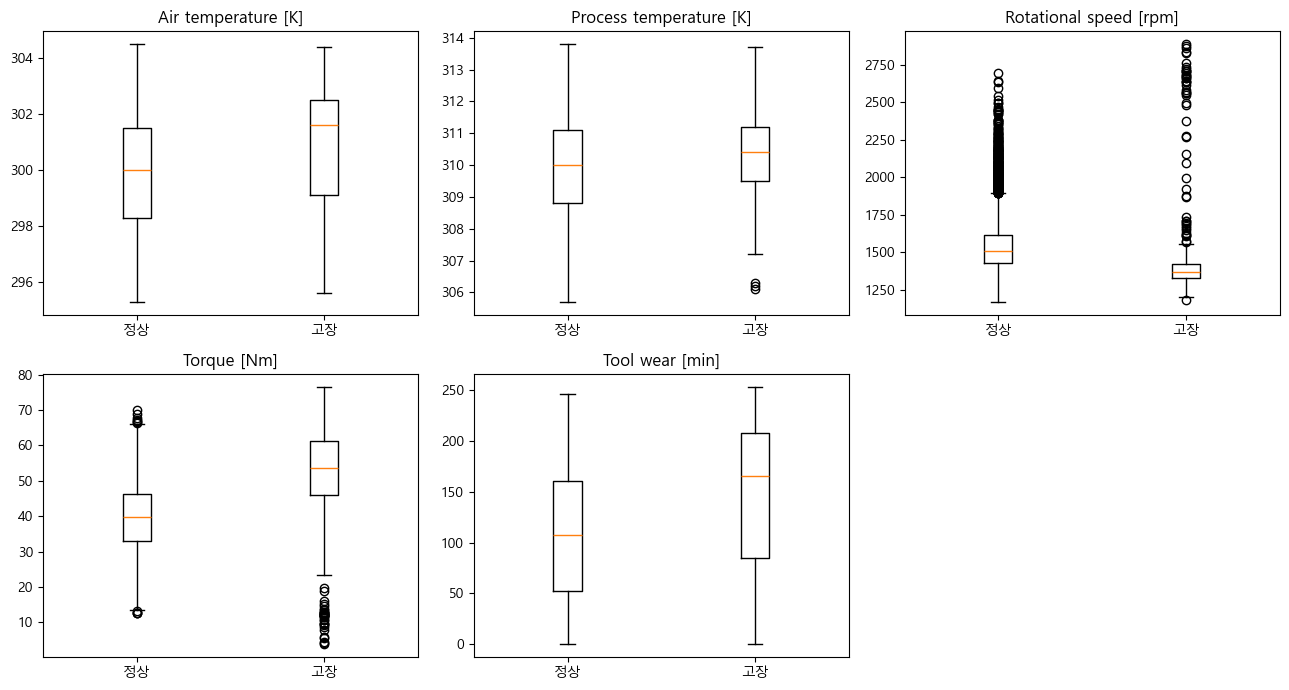

                            정상평균     고장평균     차이
sensor                                          
Air temperature [K]       299.97   300.89   0.91
Process temperature [K]   310.00   310.29   0.29
Rotational speed [rpm]   1540.26  1496.49 -43.77
Torque [Nm]                39.63    50.17  10.54
Tool wear [min]           106.69   143.78  37.09


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), sensors):
    ax.boxplot([df.loc[df[target] == 0, c], df.loc[df[target] == 1, c]],
               tick_labels=['정상', '고장'])
    ax.set_title(c)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig(FIGDIR / '01_feature_vs_target.png', dpi=120)
plt.show()

summ = []
for c in sensors:
    g0 = df.loc[df[target] == 0, c].mean()
    g1 = df.loc[df[target] == 1, c].mean()
    summ.append({'sensor': c, '정상평균': round(g0, 2),
                 '고장평균': round(g1, 2), '차이': round(g1 - g0, 2)})
print(pd.DataFrame(summ).set_index('sensor').to_string())

## 8. 제품 등급(L/M/H)별 차이 - 등급이 무엇을 바꾸는가

      count  fail_%
Type               
H      1003    2.09
L      6000    3.92
M      2997    2.77


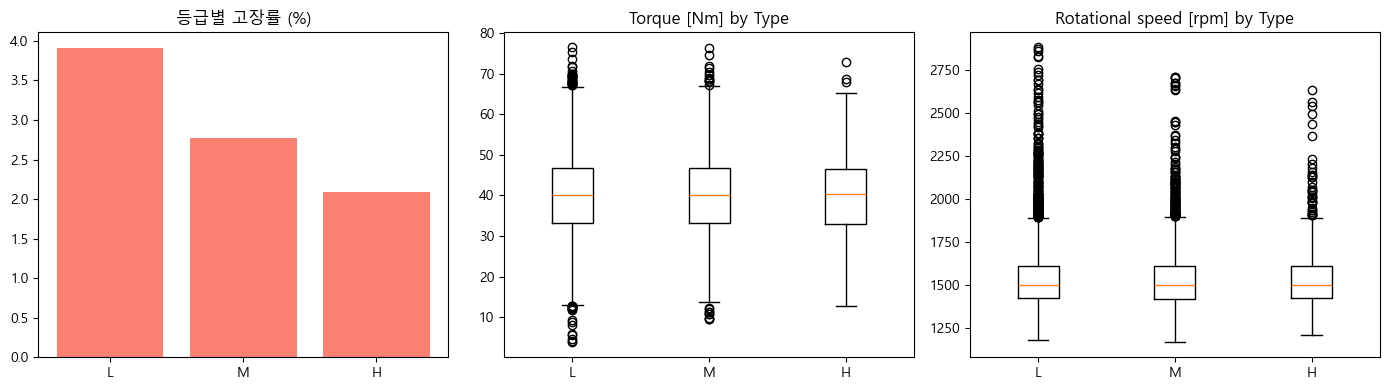

In [12]:
# 등급별 고장률
by_type = df.groupby('Type')[target].agg(['mean', 'count'])
by_type['fail_%'] = by_type['mean'] * 100
print(by_type[['count', 'fail_%']].round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
order = ['L', 'M', 'H']
axes[0].bar(order, [by_type.loc[t, 'fail_%'] for t in order], color='salmon')
axes[0].set_title('등급별 고장률 (%)')

# 토크/회전속도를 등급별 박스플롯
for ax, col in zip(axes[1:], ['Torque [Nm]', 'Rotational speed [rpm]']):
    data = [df.loc[df.Type == t, col].values for t in order]
    ax.boxplot(data, tick_labels=order)
    ax.set_title(f'{col} by Type')
plt.tight_layout()
plt.savefig(FIGDIR / '01_by_type.png', dpi=120)
plt.show()

## 9. Phase 1 결론 & Phase 2로 넘길 가설

- **불균형이 심함(고장 3.39%)** -> 모델링(Phase 4)에서 recall 중심 지표 + 불균형 처리 필요.
- **고장유형별 발생 조건이 다를 것** -> Phase 3에서 유형별로 나눠 분석.
- **센서 대부분 비정규** -> Phase 3 검정은 비모수(Mann-Whitney) 기본.
- **회전속도-토크 음의 상관** -> 동력 P=tau*omega 파생이 의미 있을 것(Phase 2).
- **등급(L/M/H)이 임계에 영향** -> 과부하(OSF) 분석은 등급별로 분리(Phase 3).